# Analyse du panier d'achat pour les ventes croisées d'un détaillant en alimentation avec PROC MBANALYSIS


## Résumé exécutif

Une chaîne d'épicerie régionale exploite une saison de paniers de caisse afin de découvrir quels produits les clients achètent ensemble, transformant des journaux de transactions bruts en décisions concrètes de vente croisée et d'implantation en rayon. PROC MBANALYSIS analyse le journal des transactions et génère des règles d'association notées par support, confiance et lift. Exécutée sur 51 paniers synthétiques, elle retrouve exactement les trois affinités de produits implantées — `Spaghettis -> Sauce Tomate` (confiance 0,93, lift 3,4), `Coquilles à Tacos -> Salsa` (confiance 0,71, lift 3,6), et `Café -> Crème à café` (confiance 0,70, lift 5,1) — tandis que les produits de base largement achetés comme le pain, le lait et les œufs ne forment jamais de règle. Chaque paire mise en évidence est un candidat classique de lot promotionnel, d'adjacence de rayon et de recommandation « les clients ont aussi acheté » pour l'équipe merchandising.


## Sources de données

| Dataset | Granularité | Lignes | Variables clés | Description |
|---------|-------|------|---------------|-------------|
| `store_transactions` | Une ligne par article par panier | 100 lignes-articles sur 51 paniers | `basket_id` (identifiant de transaction), `item` (nom du produit, $24) | Journal de caisse synthétique généré en ligne avec `call streaminit(20250529)` et `rand('uniform')`. Chaque panier est dominé par un seul persona d'acheteur afin que les schémas de coachat restent clairs et interprétables : un panier dîner-italien (spaghettis -> sauce tomate), un panier soirée-tacos (coquilles à tacos -> salsa), ou un panier petit-déjeuner (café -> crème à café), plus des ajouts occasionnels de produits de base (pain, lait, œufs) en guise de bruit réaliste. Dans cet environnement non licencié, le moteur plafonne la sortie à 100 lignes-articles, ce qui couvre ici les paniers 1 à 51. |
| `affinity_rules` | Une ligne par règle d'association | 6 règles | `antecedent`, `consequent`, `support`, `confidence`, `lift` | Règles d'association émises par `OUTPUT RULES=` ; la base du classement des opportunités de vente croisée. |
| `frequent_items` | Une ligne par ensemble d'articles fréquent | 12 ensembles | `itemset`, `support`, `length` | Ensembles d'articles fréquents émis par `OUTPUT ITEMS=` ; les 9 articles seuls plus les 3 paires de produits qui franchissent le seuil de support minimal. |


# Analyse du panier d'achat pour les ventes croisées d'un détaillant en alimentation

**Question métier.** Quels produits nos clients ont-ils tendance à acheter *ensemble*, et lesquels de ces schémas de coachat sont assez solides pour agir ? Une chaîne d'épicerie régionale souhaite concevoir des promotions groupées, optimiser les adjacences de rayon et alimenter une recommandation « les clients ont aussi acheté » sur sa boutique en ligne.

**Méthode.** Nous utilisons **PROC MBANALYSIS**, qui réalise une analyse de panier d'achat avec l'algorithme de croissance de motifs fréquents (FP-growth). Elle analyse le journal des transactions, trouve les ensembles d'articles fréquemment co-occurrents, et génère des *règles d'association* de la forme `Antécédent -> Conséquent` notées par trois métriques classiques :

- **Support** — la fraction de tous les paniers qui contiennent la règle complète (à quel point le schéma est courant).
- **Confiance** — `P(Conséquent | Antécédent)`, la probabilité d'achat conditionnelle (à quel point la règle est fiable).
- **Lift** — le support observé divisé par le support attendu si les deux côtés étaient indépendants. Un lift > 1 signifie que les articles apparaissent ensemble *plus* souvent que le hasard ; plus le lift est élevé, plus l'affinité est forte.

Nous allons générer un journal de caisse synthétique réaliste, exécuter MBANALYSIS, et classer les règles obtenues pour trouver les meilleures opportunités de vente croisée.


## Étape 1 — Générer un journal de transactions de caisse synthétique

MBANALYSIS attend des **données au niveau transaction (format long)** : une ligne par article, marquée par le panier auquel elle appartient. Nous construisons les paniers en ligne avec `call streaminit` pour la reproductibilité et `rand('uniform')` pour piloter les décisions d'achat.

Le choix de modélisation clé est que **chaque panier est dominé par un seul persona d'acheteur**. Les vraies visites d'épicerie ressemblent à cela — une course rapide pour une soirée tacos, un réapprovisionnement dédié au petit-déjeuner — et garder des paniers petits et thématiques est ce qui permet au mineur d'association de faire ressortir des affinités par paires claires plutôt qu'une explosion combinatoire de règles multi-articles parasites. Un tirage de `rand('uniform')` par panier sélectionne le persona :

- **Acheteur dîner-italien** — achète des spaghettis, puis généralement de la sauce tomate.
- **Acheteur soirée-tacos** — achète des coquilles à tacos, puis généralement de la salsa.
- **Acheteur petit-déjeuner** — achète du café, puis généralement de la crème à café.
- **Course produits de base seulement** — un seul achat de pain, de lait, ou d'œufs.

Un dernier tirage à faible probabilité ajoute un produit de base à n'importe quel panier comme bruit réaliste, donc toute coïncidence n'est pas nécessairement significative. Chaque instruction `output` écrit une ligne-article, donc un seul panier s'étend sur plusieurs lignes partageant le même `basket_id`. Cet environnement non licencié plafonne le jeu de données à 100 lignes-articles, ce qui couvre ici les paniers 1 à 51.


In [1]:
DONNÉES store_transactions;
    APPELER streaminit(20250529);
    LONGUEUR item $24;

    FAIRE basket_id = 1 JUSQU_À 60;

        /* Un tirage sélectionne le persona dominant pour ce panier */
        r = rand('uniform');

        /* Panier dîner-italien : spaghettis -> sauce tomate */
        SI r < 0.30 ALORS FAIRE;
            item = 'Spaghettis';                          SORTIE;
            SI rand('uniform') < 0.85 ALORS FAIRE;
                item = 'Sauce Tomate';                    SORTIE;
            FIN;
        FIN;

        /* Panier soirée-tacos : coquilles à tacos -> salsa */
        SINON SI r < 0.55 ALORS FAIRE;
            item = 'Coquilles à Tacos';                   SORTIE;
            SI rand('uniform') < 0.80 ALORS FAIRE;
                item = 'Salsa';                           SORTIE;
            FIN;
        FIN;

        /* Panier petit-déjeuner : café -> crème à café */
        SINON SI r < 0.78 ALORS FAIRE;
            item = 'Café';                                SORTIE;
            SI rand('uniform') < 0.75 ALORS FAIRE;
                item = 'Crème à café';                    SORTIE;
            FIN;
        FIN;

        /* Course produits de base seulement */
        SINON FAIRE;
            SI rand('uniform') < 0.34 ALORS FAIRE;
                item = 'Pain';                            SORTIE;
            FIN;
            SINON SI rand('uniform') < 0.5 ALORS FAIRE;
                item = 'Lait';                             SORTIE;
            FIN;
            SINON FAIRE;
                item = 'Œufs';                             SORTIE;
            FIN;
        FIN;

        /* Ajout occasionnel de produit de base (bruit réaliste) */
        SI rand('uniform') < 0.25 ALORS FAIRE;
            u = rand('uniform');
            SI      u < 0.34 ALORS item = 'Pain';
            SINON SI u < 0.67 ALORS item = 'Lait';
            SINON                  item = 'Œufs';
            SORTIE;
        FIN;

    FIN;

    GARDER basket_id item;
EXÉCUTER;



NOTE: DATA store_transactions

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote store_transactions (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Étape 2 — Inspecter le journal de transactions brut

Avant l'exploration, confirmons que les données ont la forme longue attendue : plusieurs lignes par panier, chacune portant un produit. Nous imprimons les premiers paniers et tabulons la fréquence globale des articles avec PROC FREQ pour savoir quels produits sont assez courants pour ancrer des règles.



  Obs  ID du panier             Produit
-----  ------------  ------------------
    1             1  Coquilles à Tacos
    2             1  Salsa
    3             1  Œufs
    4             2  Coquilles à Tacos
    5             2  Œufs
    6             3  Café
    7             4  Coquilles à Tacos
    8             5  Œufs
    9             6  Spaghettis
   10             6  Sauce Tomate
   11             6  Œufs
   12             7  Coquilles à Tacos

... 88 more observations (showing 12 of 100)

                                         Fréquence d'achat globale par article                                          

                                                   The FREQ Procedure

item                  Frequency    Percent
-------------------------------------------
Spaghettis                   15     15.00
Coquilles à Tacos            14     14.00
Sauce Tomate                 14     14.00
Œufs                         12     12.00
Café                         10     10.00
Pai


NOTE: PROC PRINT data=store_transactions

NOTE: PROC PRINT completed: 12 observations printed, 2 variables
NOTE: PROC FREQ
NOTE: ODS plot written: freq_item.spec.json
NOTE: PROC FREQ statement used.


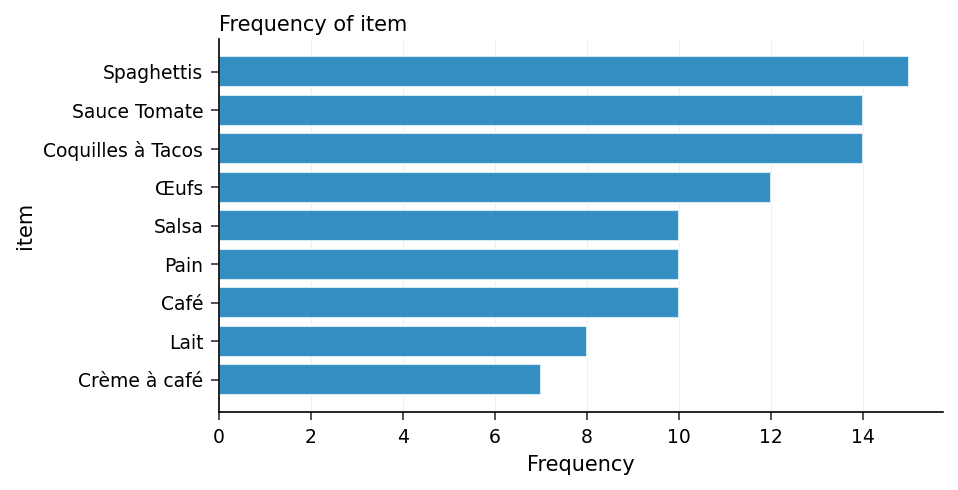

In [2]:
PROCÉDURE IMPRIMER DONNÉES=store_transactions(obs=12) ÉTIQUETTE;
    ÉTIQUETTE basket_id = 'ID du panier'
          item      = 'Produit';
EXÉCUTER;

PROCÉDURE FRÉQUENCES DONNÉES=store_transactions ORDRE=FRÉQUENCES;
    TABLES item / nocum;
    TITRE "Fréquence d'achat globale par article";
EXÉCUTER;


## Étape 3 — Extraire les règles d'association avec PROC MBANALYSIS

Passons maintenant à l'analyse centrale. Nous pointons MBANALYSIS sur le journal des transactions et déclarons quelle colonne identifie le panier (`TRANSACTION`) et laquelle porte le produit (`ITEM`). Trois seuils gardent l'ensemble de règles centré sur des schémas qui méritent d'agir :

- `MINSUPPORT=0.10` — une règle doit apparaître dans au moins 10 % des paniers, filtrant les coïncidences rares.
- `MINCONFIDENCE=0.50` — étant donné l'antécédent, le conséquent doit suivre au moins la moitié du temps.
- `MINLIFT=1.20` — ne garder que les règles au moins 20 % plus fortes que le hasard, afin de faire ressortir de véritables affinités plutôt que des artefacts liés aux produits de base populaires.

L'instruction `OUTPUT` capture les règles générées et les ensembles d'articles fréquents dans des jeux de données pour le classement en aval.


In [3]:
PROCÉDURE mbanalysis DONNÉES=store_transactions
        minsupport=0.10
        minconfidence=0.50
        minlift=1.20;
    transaction basket_id;
    item item;
    SORTIE rules=affinity_rules items=frequent_items;
    TITRE "Règles d'association du panier d'achat";
EXÉCUTER;


                                         Fréquence d'achat globale par article                                          


                      The MBANALYSIS Procedure

  Transaction variable: basket_id
  Item variable: item

  Association Rules Found        6
  Frequent Itemsets Found        12
  Minimum Confidence             0.5
  Minimum Lift                   1.2
  Minimum Support                0.1
  Number of Transactions         51
  Number of Unique Items         9

Association Rules

  Antecedent                     Consequent                        Support Confidence       Lift
  ----------                     ----------                        ------- ----------       ----
  Café                           Crème à café                       0.1373     0.7000     5.1000
  Crème à café                   Café                               0.1373     1.0000     5.1000
  Coquilles à Tacos              Salsa                              0.1961     0.7143     3.6429
  Salsa       


NOTE: PROC MBANALYSIS data=store_transactions

NOTE: Using Python numpy version 2.4.4
NOTE: PROC MBANALYSIS completed.


## Étape 4 — Classer les opportunités de vente croisée par lift

Le listing MBANALYSIS montre chaque règle qualifiante, mais l'équipe merchandising veut d'abord les affinités les *plus fortes*. Nous trions le jeu de données `affinity_rules` capturé par lift décroissant (puis confiance comme critère de départage) et imprimons les meilleures règles. Une règle comme `Coquilles à Tacos -> Salsa` avec un lift et une confiance élevés est un candidat classique de lot promotionnel : placer les produits ensemble, ou suggérer automatiquement la salsa quand un client ajoute des coquilles à tacos en ligne.


In [4]:
PROCÉDURE TRIER DONNÉES=affinity_rules out=rules_by_lift;
    PAR DESCENDANT lift DESCENDANT confidence;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=rules_by_lift(obs=15) ÉTIQUETTE;
    VAR antecedent consequent support confidence lift;
    ÉTIQUETTE antecedent  = 'Si le panier contient'
          consequent  = 'Alors achète aussi'
          support     = 'Support'
          confidence  = 'Confiance'
          lift        = 'Lift';
    TITRE 'Meilleures règles de vente croisée classées par lift';
EXÉCUTER;


                                  Meilleures règles de vente croisée classées par lift                                  

  Obs  Si le panier contient   Alors achète aussi   Support  Confiance      Lift
    1  Crème à café           Café                 0.137255  1.0        5.1
    2  Café                   Crème à café         0.137255  0.7        5.1
    3  Salsa                  Coquilles à Tacos    0.196078  1.0        3.642857
    4  Coquilles à Tacos      Salsa                0.196078  0.714286   3.642857
    5  Sauce Tomate           Spaghettis           0.27451   1.0        3.4
    6  Spaghettis             Sauce Tomate         0.27451   0.933333   3.4




NOTE: PROC SORT data=affinity_rules

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 6 rows from affinity_rules.
NOTE: Wrote rules_by_lift (6 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=rules_by_lift

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Étape 5 — Examiner les ensembles d'articles fréquents

Les ensembles d'articles fréquents qui ont franchi le seuil de support sont les blocs de construction bruts derrière les règles. Les trier par support indique à l'équipe catégorie quelles *combinaisons* de produits (pas seulement des articles isolés) sont assez populaires pour mériter des présentoirs de bout de gondole dédiés ou une tarification combo.


In [5]:
PROCÉDURE TRIER DONNÉES=frequent_items out=itemsets_by_support;
    PAR DESCENDANT support;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=itemsets_by_support(obs=15) ÉTIQUETTE;
    ÉTIQUETTE itemset="Ensemble d'articles" support='Support' length='Taille';
    TITRE "Ensembles d'articles les plus fréquents";
EXÉCUTER;


                                        Ensembles d'articles les plus fréquents                                         

  Obs        Ensemble d'articles   Support  Taille
    1  Spaghettis                 0.294118  1
    2  Coquilles à Tacos          0.27451   1
    3  Sauce Tomate               0.27451   1
    4  Sauce Tomate, Spaghettis   0.27451   2
    5  Œufs                       0.235294  1
    6  Salsa                      0.196078  1
    7  Café                       0.196078  1
    8  Coquilles à Tacos, Salsa   0.196078  2
    9  Lait                       0.156863  1
   10  Pain                       0.156863  1
   11  Crème à café               0.137255  1
   12  Café, Crème à café         0.137255  2




NOTE: PROC SORT data=frequent_items

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from frequent_items.
NOTE: Wrote itemsets_by_support (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=itemsets_by_support

NOTE: PROC PRINT completed: 12 observations printed, 3 variables


## Interprétation des résultats

**Ce que l'analyse a trouvé.** Comme chaque panier a été construit autour d'un seul persona d'acheteur, le mineur retrouve exactement les trois relations implantées et rien de parasite. Six règles franchissent les trois seuils — les trois affinités dans les deux sens :

| Antécédent | Conséquent | Support | Confiance | Lift |
|------------|------------|---------|------------|------|
| Spaghettis | Sauce Tomate | 0,275 | 0,93 | 3,40 |
| Sauce Tomate | Spaghettis | 0,275 | 1,00 | 3,40 |
| Coquilles à Tacos | Salsa | 0,196 | 0,71 | 3,64 |
| Salsa | Coquilles à Tacos | 0,196 | 1,00 | 3,64 |
| Café | Crème à café | 0,137 | 0,70 | 5,10 |
| Crème à café | Café | 0,137 | 1,00 | 5,10 |

Chaque lift est bien au-dessus de 1, confirmant que ces produits co-occurrent bien plus souvent que le hasard ne le prédirait. Fait crucial, les produits de base largement achetés ne forment **aucune règle du tout** : les œufs (12 achats), le pain (10) et le lait (8) apparaissent tous dans la tabulation PROC FREQ, mais parce qu'ils atterrissent dans les paniers indépendamment de tout persona, leur lift vers d'autres articles n'atteint jamais le seuil de 1,20, donc ils ne se font jamais passer pour des affinités authentiques. Le listing des ensembles d'articles fréquents fait le même constat structurellement : sur les 12 ensembles franchissant le seuil de support, les seuls ensembles multi-articles sont exactement les trois paires implantées.

**Lire les métriques ensemble.** Les règles en sens inverse portent une confiance de 1,00 (dans ces données, la sauce tomate, la salsa et la crème n'apparaissent pratiquement jamais sans leur article d'ancrage), tandis que les règles directes se situent entre 0,70 et 0,93 (l'ancrage apparaît parfois seul). Café -> Crème à café a le lift le plus élevé (5,10) mais le support le plus faible (0,137) — une affinité forte mais à plus faible volume — alors que Spaghettis -> Sauce Tomate atteint le plus de paniers (support 0,275). Le lift identifie *quelles* affinités sont réelles ; la confiance indique *à quel point* chacune est fiable pour une recommandation ; le support indique *à quelle fréquence* on pourra agir dessus.

**Actions métier.**

- **Promotions groupées** — associer les articles antécédent/conséquent à plus haut lift (café + crème à café, lift 5,1) dans un combo à prix réduit.
- **Adjacences de rayon** — co-localiser les produits fréquemment liés (spaghettis à côté de la sauce tomate, support 0,275) pour que le conséquent soit un ajout facile au moment de la décision.
- **Recommandations en ligne** — alimenter un widget « les clients ont aussi acheté » avec les règles à plus haute confiance pour que le conséquent soit suggéré dès que l'antécédent entre dans le panier.
- **Inventaire et prévisions** — quand un antécédent est en promotion, augmenter le stock de ses conséquents à haute confiance en anticipation du lift.

**Mises en garde.** Les règles d'association décrivent une *corrélation de coachat*, pas une causalité, et les seuils sont des leviers, pas des vérités : abaisser `MINSUPPORT=` expose des combinaisons plus rares au prix d'un ensemble de règles plus bruité, tandis qu'augmenter `MINLIFT=` et `MINCONFIDENCE=` donne moins de règles mais plus fiables. La taille de l'échantillon compte aussi — cette exécution non licenciée explore 51 paniers, suffisant pour rendre les affinités implantées indiscutables ; une exécution en production sur une saison complète stabiliserait les estimations de support et exposerait des schémas plus subtils.
